# European language competence

In [ ]:
"""
European Official Language Speakers - Flag Bubble Scatter Plot
Requirements: pip install matplotlib requests pillow numpy
"""

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np
import urllib.request
from PIL import Image
import io

In [7]:
# ── Data ──────────────────────────────────────────────────────────────────────
countries = [
    # (name, ISO2, population_millions, pct_speaking_official)
    ("Albania",         "al", 2.8,   98),
    # ("Andorra",         "ad", 0.08,  70),
    ("Austria",         "at", 9.1,   99),
    ("Belarus",         "by", 9.4,   99),
    ("Belgium",         "be", 11.6,  99),
    ("Bosnia & Herz.",  "ba", 3.3,   99),
    ("Bulgaria",        "bg", 6.5,   95),
    ("Croatia",         "hr", 4.0,   99),
    ("Cyprus",          "cy", 1.2,   99),
    ("Czech Republic",  "cz", 10.9,  98),
    ("Denmark",         "dk", 5.9,   99),
    ("Estonia",         "ee", 1.4,   84),
    ("Finland",         "fi", 5.5,   99),
    ("France",          "fr", 68.0,  99),
    ("Germany",         "de", 84.0,  99),
    ("Greece",          "gr", 10.4,  99),
    ("Hungary",         "hu", 9.7,   99),
    ("Iceland",         "is", 0.37,  98),
    ("Ireland",         "ie", 5.1,   99),
    ("Italy",           "it", 59.0,  98),
    ("Latvia",          "lv", 1.8,   80),
    ("Lithuania",       "lt", 2.8,   95),
    ("Luxembourg",      "lu", 0.66,  99),
    ("Malta",           "mt", 0.54,  99),
    ("Moldova",         "md", 2.6,   93),
    ("Montenegro",      "me", 0.62,  98),
    ("Netherlands",     "nl", 17.7,  99),
    ("North Macedonia", "mk", 2.1,   97),
    ("Norway",          "no", 5.4,   99),
    ("Poland",          "pl", 37.8,  99),
    ("Portugal",        "pt", 10.3,  99),
    ("Romania",         "ro", 19.0,  95),
    ("Serbia",          "rs", 6.8,   97),
    ("Slovakia",        "sk", 5.5,   96),
    ("Slovenia",        "si", 2.1,   97),
    ("Spain",           "es", 47.4,  99),
    ("Sweden",          "se", 10.5,  97),
    ("Switzerland",     "ch", 8.7,   99),
    ("Ukraine",         "ua", 43.5,  94),
    ("United Kingdom",  "gb", 67.7,  99),
]

In [8]:
names  = [c[0] for c in countries]
isos   = [c[1] for c in countries]
pops   = np.array([c[2] for c in countries])
pcts   = np.array([c[3] for c in countries])

In [9]:
# ── Colour by % tier ───────────────────────────────────────────────────────────
def tier_color(p):
    if p >= 99: return "#3B6D11"
    if p >= 95: return "#639922"
    if p >= 90: return "#BA7517"
    if p >= 85: return "#D85A30"
    return "#A32D2D"

colors = [tier_color(p) for p in pcts]

In [10]:
# ── Fetch flag images from flagcdn ────────────────────────────────────────────
def fetch_flag(iso, size=32):
    url = f"https://flagcdn.com/w{size}/{iso}.png"
    try:
        with urllib.request.urlopen(url, timeout=5) as r:
            return Image.open(io.BytesIO(r.read())).convert("RGBA")
    except Exception:
        return None

print("Fetching flags...")
flag_imgs = {iso: fetch_flag(iso) for iso in isos}
print("Done.")

Fetching flags...
Done.


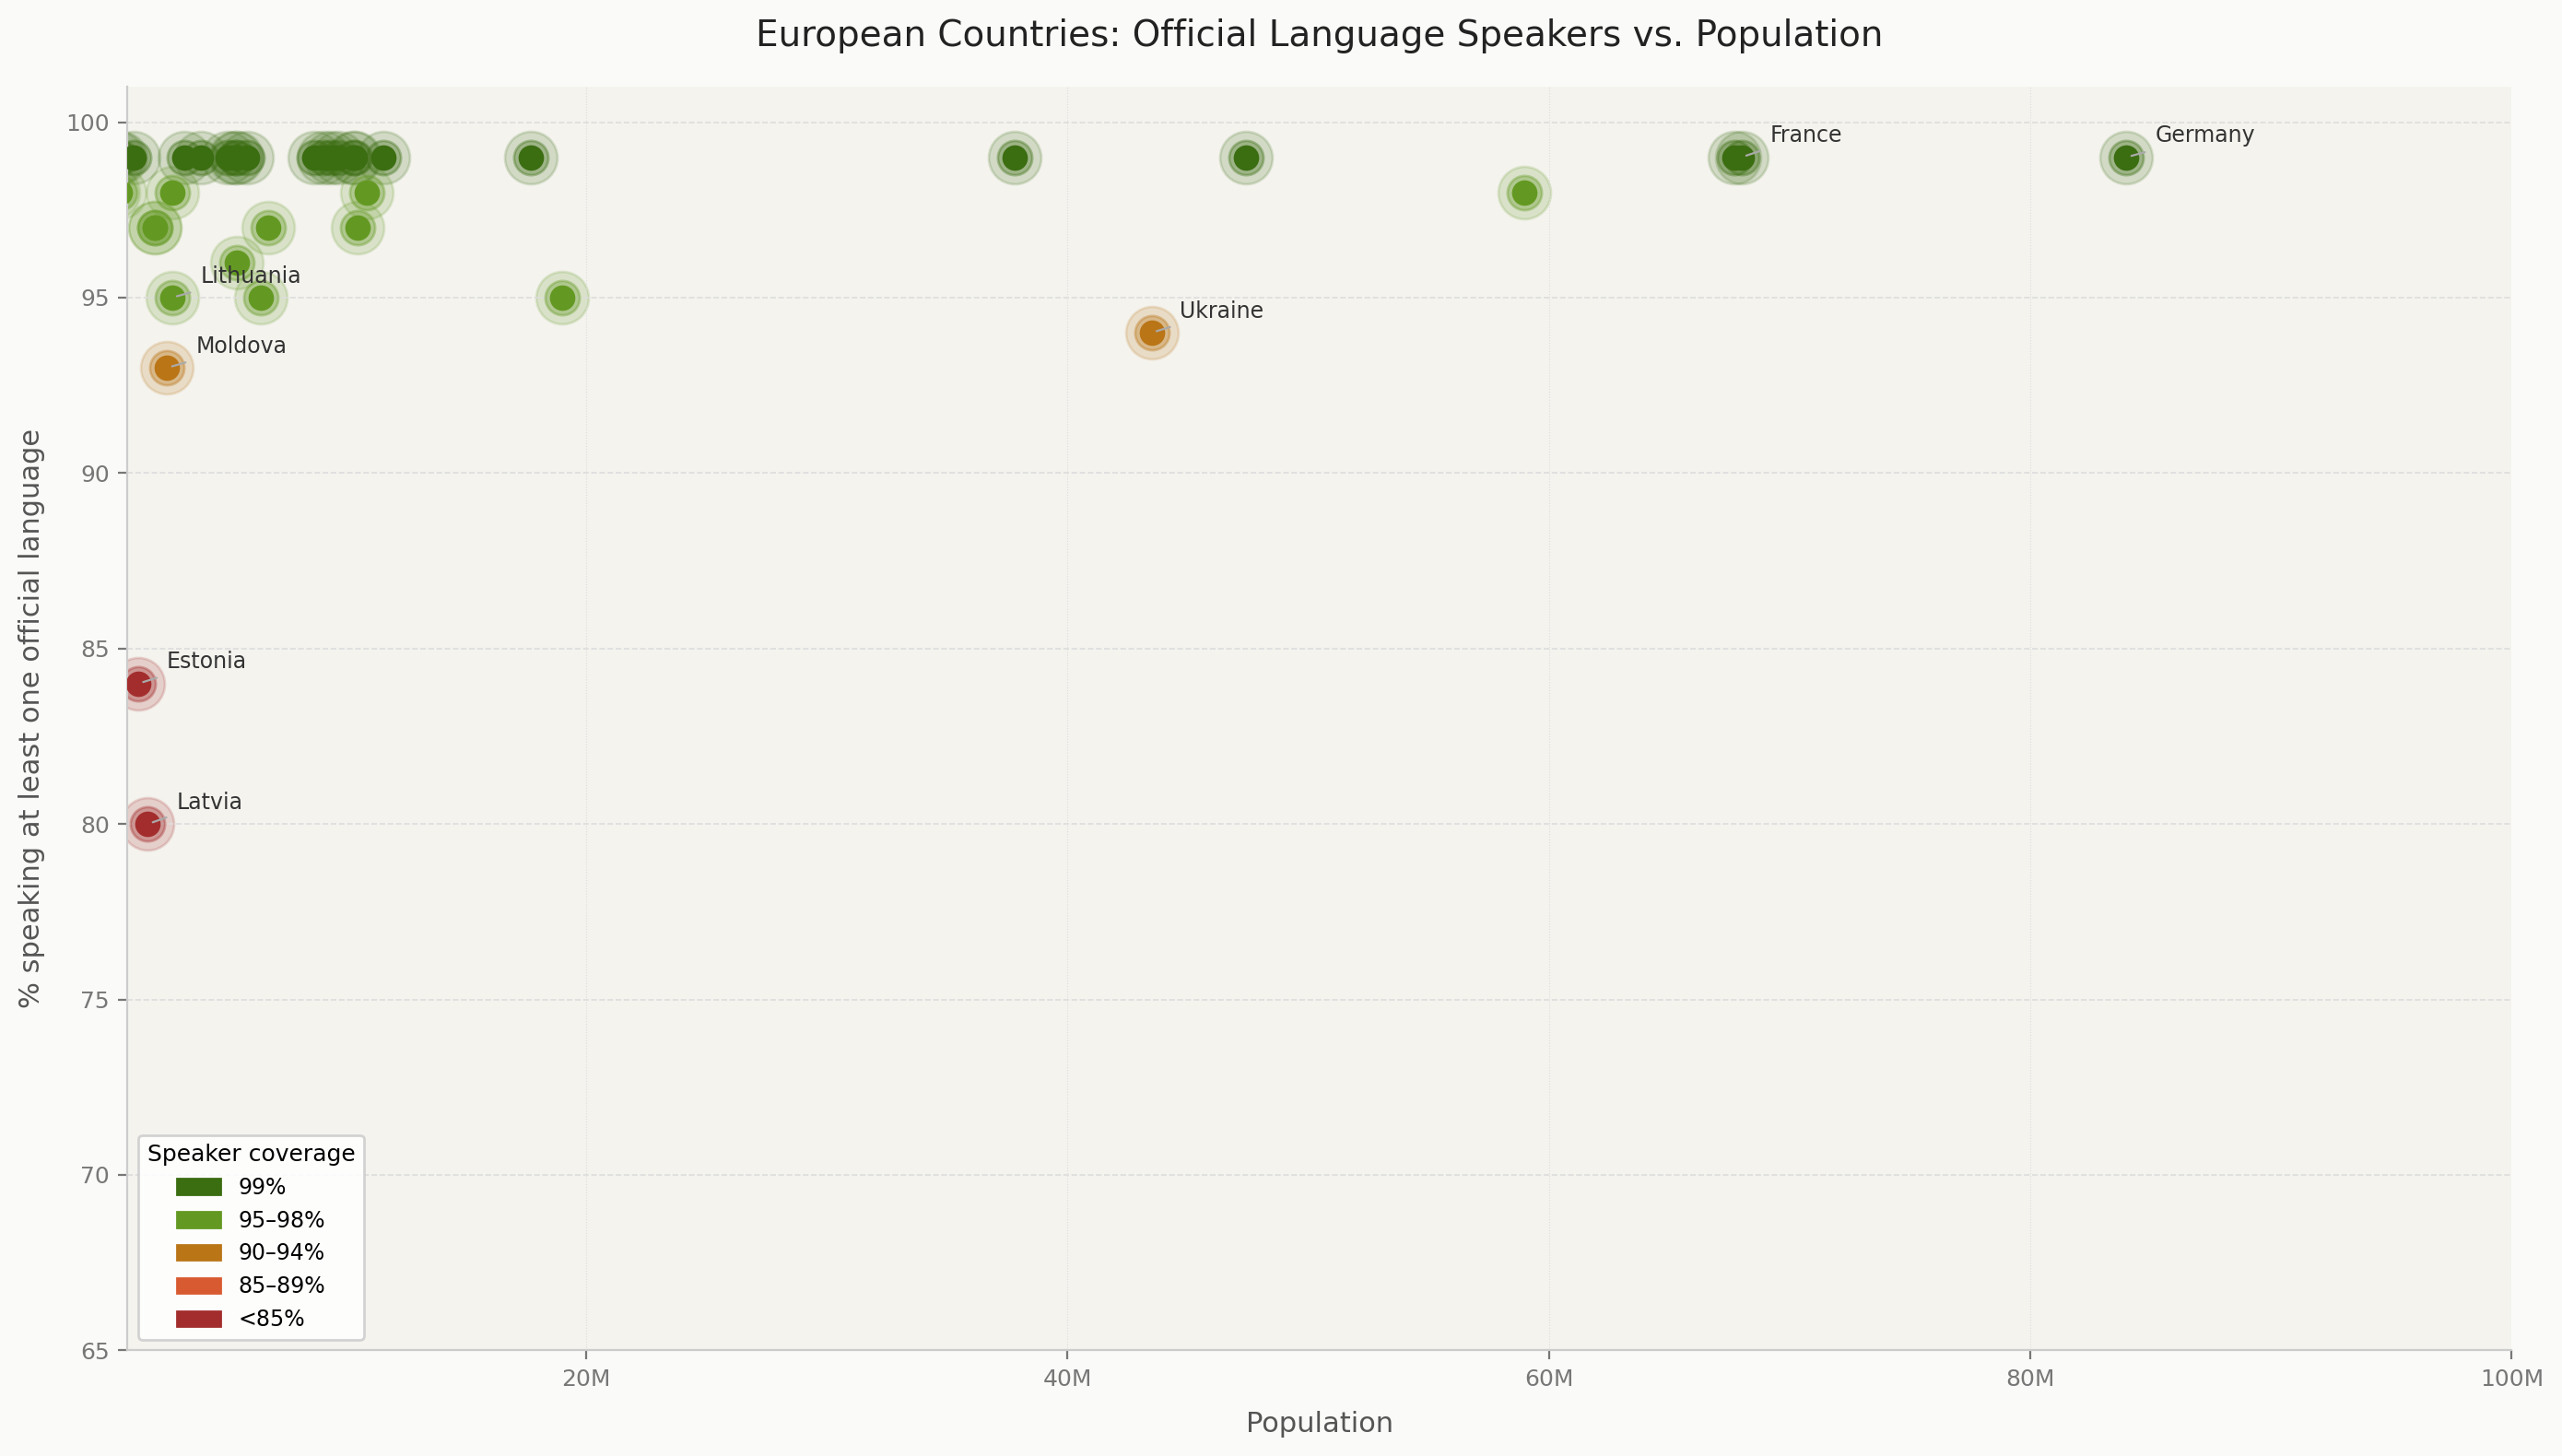

In [17]:
# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8), dpi=200)
fig.patch.set_facecolor("#FAFAF8")
ax.set_facecolor("#F4F3EE")

# Log-scale X axis
# ax.set_xscale("log")

# Scatter background glow rings (colour-coded)
for pop, pct, col in zip(pops, pcts, colors):
    ax.scatter(pop, pct, s=420, color=col, alpha=0.18, zorder=1)
    ax.scatter(pop, pct, s=180, color=col, alpha=0.35, zorder=2)

# Flag images as annotation boxes
for name, iso, pop, pct in zip(names, isos, pops, pcts):
    img = flag_imgs.get(iso)
    if img:
        im = OffsetImage(np.array(img), zoom=0.55)
        im.image.axes = ax
        ab = AnnotationBbox(
            im, (pop, pct),
            frameon=True,
            bboxprops=dict(
                boxstyle="round,pad=0.15",
                edgecolor=tier_color(pct),
                facecolor="white",
                linewidth=1.2
            ),
            zorder=3
        )
        ax.add_artist(ab)
    else:
        ax.scatter(pop, pct, s=80, color=tier_color(pct), zorder=3)

# Labels for notable outliers
outliers = {"Lithuania", "Estonia", "Latvia", "Ukraine", "Moldova",
            "Germany", "France"}
for name, iso, pop, pct in zip(names, isos, pops, pcts):
    if name in outliers:
        offset_x = pop + 1.18
        offset_y = pct + 0.3
        ax.annotate(
            name,
            xy=(pop, pct),
            xytext=(offset_x, offset_y),
            fontsize=8.5,
            color="#333",
            fontfamily="sans-serif",
            arrowprops=dict(arrowstyle="-", color="#aaa", lw=0.8),
            va="bottom"
        )

# Grid & axes
ax.set_xlabel("Population", fontsize=11, color="#555", labelpad=8)
ax.set_ylabel("% speaking at least one official language", fontsize=11, color="#555", labelpad=8)
ax.set_title("European Countries: Official Language Speakers vs. Population",
             fontsize=14, fontweight="normal", color="#222", pad=16)

ax.set_ylim(65, 101)
ax.set_xlim(0.95, 100)
ax.xaxis.set_major_formatter(plt.FuncFormatter(
    lambda x, _: f"{x:g}M"
))
ax.tick_params(colors="#777", labelsize=9)
ax.spines[["top","right"]].set_visible(False)
ax.spines[["left","bottom"]].set_color("#ccc")
ax.grid(axis="y", color="#ddd", linewidth=0.6, linestyle="--", zorder=0)
ax.grid(axis="x", color="#ddd", linewidth=0.4, linestyle=":", zorder=0)

# Legend
legend_items = [
    mpatches.Patch(color="#3B6D11", label="99%"),
    mpatches.Patch(color="#639922", label="95–98%"),
    mpatches.Patch(color="#BA7517", label="90–94%"),
    mpatches.Patch(color="#D85A30", label="85–89%"),
    mpatches.Patch(color="#A32D2D", label="<85%"),
]
ax.legend(handles=legend_items, title="Speaker coverage", title_fontsize=9,
          fontsize=8.5, loc="lower left", framealpha=0.85,
          edgecolor="#ccc", facecolor="white")

plt.tight_layout()
# plt.savefig("/mnt/user-data/outputs/european_language_chart.png",
#             dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
# print("Saved: european_language_chart.png")
plt.show()

Saved: european_language_chart.png


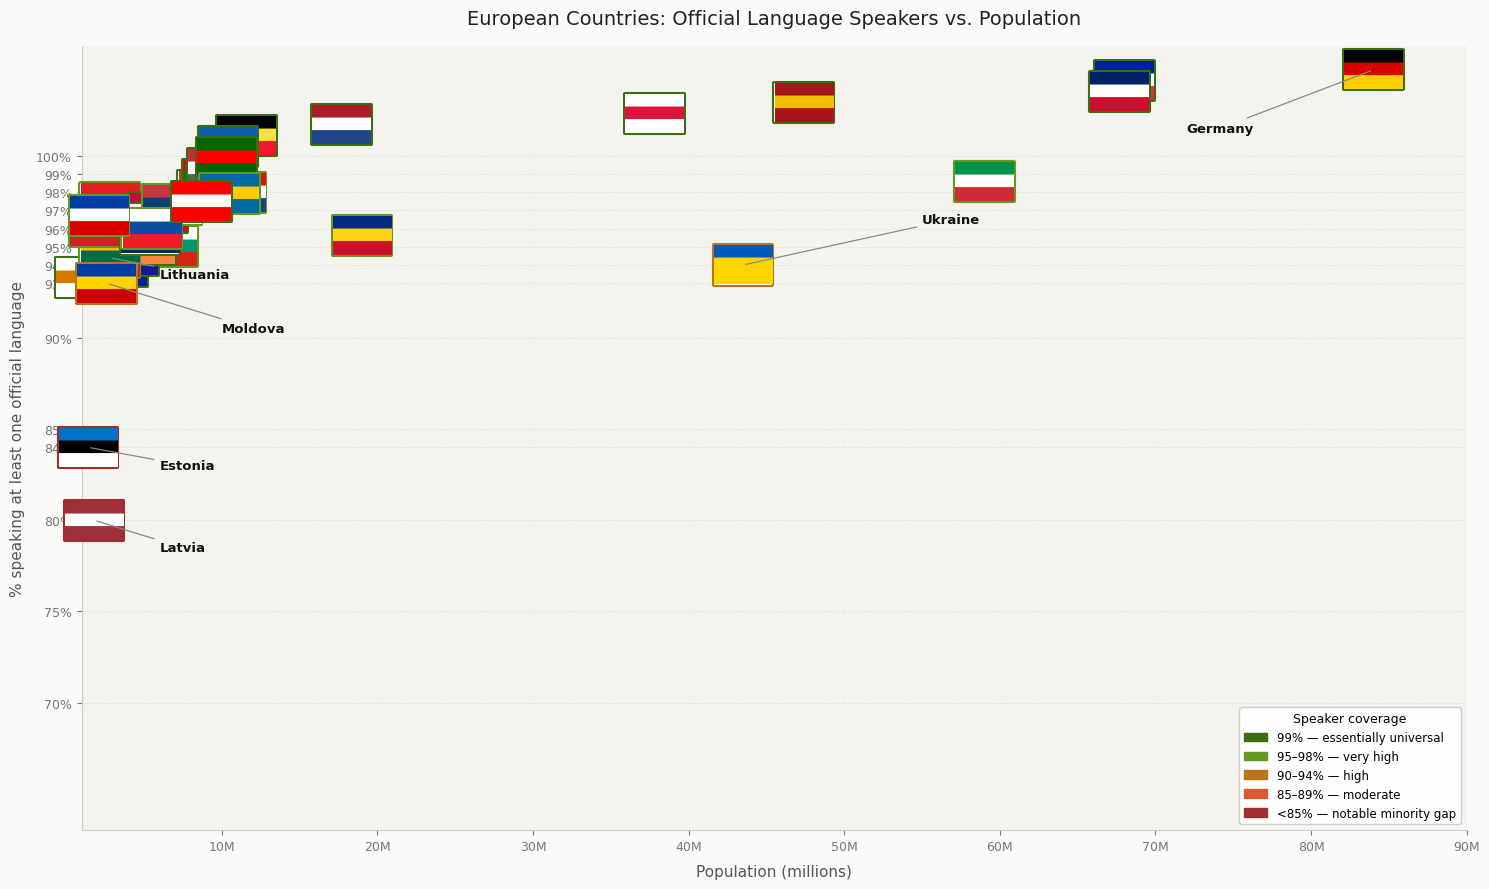

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

FLAG_STRIPES = {
    "al": ["#E41E20","#000000","#E41E20"], "at": ["#ED2939","#FFFFFF","#ED2939"],
    "by": ["#CF101A","#007F00","#CF101A"], "be": ["#000000","#FAE042","#F31830"],
    "ba": ["#002395","#FFCD00","#002395"], "bg": ["#FFFFFF","#00966E","#D62612"],
    "hr": ["#FF0000","#FFFFFF","#171796"], "cy": ["#FFFFFF","#D57800","#FFFFFF"],
    "cz": ["#D7141A","#FFFFFF","#11457E"], "dk": ["#C60C30","#FFFFFF","#C60C30"],
    "ee": ["#0072CE","#000000","#FFFFFF"], "fi": ["#FFFFFF","#003580","#FFFFFF"],
    "fr": ["#002395","#FFFFFF","#ED2939"], "de": ["#000000","#DD0000","#FFCE00"],
    "gr": ["#0D5EAF","#FFFFFF","#0D5EAF"], "hu": ["#CE2939","#FFFFFF","#436F4D"],
    "is": ["#003897","#FFFFFF","#D72828"], "ie": ["#169B62","#FFFFFF","#FF883E"],
    "it": ["#009246","#FFFFFF","#CE2B37"], "lv": ["#9E3039","#FFFFFF","#9E3039"],
    "lt": ["#FDB913","#006A44","#C1272D"], "lu": ["#EF3340","#FFFFFF","#00A3E0"],
    "mt": ["#FFFFFF","#CF142B","#FFFFFF"], "md": ["#003DA5","#FFD200","#CC0001"],
    "me": ["#D4AF37","#C40308","#D4AF37"], "nl": ["#AE1C28","#FFFFFF","#21468B"],
    "mk": ["#CE2028","#F7E30E","#CE2028"], "no": ["#EF2B2D","#FFFFFF","#002868"],
    "pl": ["#FFFFFF","#DC143C","#FFFFFF"], "pt": ["#006600","#FF0000","#006600"],
    "ro": ["#002B7F","#FCD116","#CE1126"], "rs": ["#C6363C","#0C4076","#FFFFFF"],
    "sk": ["#FFFFFF","#0B4EA2","#EE1C25"], "si": ["#003DA5","#FFFFFF","#DD0000"],
    "es": ["#AA151B","#F1BF00","#AA151B"], "se": ["#006AA7","#FECC02","#006AA7"],
    "ch": ["#FF0000","#FFFFFF","#FF0000"], "ua": ["#005BBB","#FFD500","#FFD500"],
    "gb": ["#012169","#FFFFFF","#C8102E"],
}

# Countries with population >= 1M (excludes Iceland, Luxembourg, Malta, Montenegro)
countries = [
    ("Albania","al",2.8,98), ("Austria","at",9.1,99),
    ("Belarus","by",9.4,99), ("Belgium","be",11.6,99), ("Bosnia & Herz.","ba",3.3,99),
    ("Bulgaria","bg",6.5,95), ("Croatia","hr",4.0,99), ("Cyprus","cy",1.2,99),
    ("Czech Republic","cz",10.9,98), ("Denmark","dk",5.9,99), ("Estonia","ee",1.4,84),
    ("Finland","fi",5.5,99), ("France","fr",68.0,99), ("Germany","de",84.0,99),
    ("Greece","gr",10.4,99), ("Hungary","hu",9.7,99),
    ("Ireland","ie",5.1,99), ("Italy","it",59.0,98), ("Latvia","lv",1.8,80),
    ("Lithuania","lt",2.8,95), ("Moldova","md",2.6,93),
    ("Netherlands","nl",17.7,99), ("North Macedonia","mk",2.1,97), ("Norway","no",5.4,99),
    ("Poland","pl",37.8,99), ("Portugal","pt",10.3,99), ("Romania","ro",19.0,95),
    ("Serbia","rs",6.8,97), ("Slovakia","sk",5.5,96), ("Slovenia","si",2.1,97),
    ("Spain","es",47.4,99), ("Sweden","se",10.5,97), ("Switzerland","ch",8.7,99),
    ("Ukraine","ua",43.5,94), ("United Kingdom","gb",67.7,99),
]

names = [c[0] for c in countries]
isos  = [c[1] for c in countries]
pops  = np.array([c[2] for c in countries])
pcts  = np.array([c[3] for c in countries], dtype=float)

# Spread flags that share the same pct value to avoid overlap
jittered_pcts = pcts.copy()
for val in np.unique(pcts):
    idx = np.where(pcts == val)[0]
    if len(idx) > 1:
        sorted_idx = idx[np.argsort(pops[idx])]
        n = len(sorted_idx)
        offsets = np.linspace(-(n-1)/2 * 0.6, (n-1)/2 * 0.6, n)
        for i, si in enumerate(sorted_idx):
            jittered_pcts[si] = val + offsets[i]

def tier_color(p):
    if p >= 99: return "#3B6D11"
    if p >= 95: return "#639922"
    if p >= 90: return "#BA7517"
    if p >= 85: return "#D85A30"
    return "#A32D2D"

def make_flag_array(iso, px_w=42, px_h=28):
    colors_hex = FLAG_STRIPES.get(iso, ["#AAAAAA","#CCCCCC","#AAAAAA"])
    n = len(colors_hex)
    img = np.zeros((px_h, px_w, 3), dtype=np.uint8)
    rows_per = px_h // n
    for i, hx in enumerate(colors_hex):
        r,g,b = int(hx[1:3],16), int(hx[3:5],16), int(hx[5:7],16)
        start = i * rows_per
        end = start + rows_per if i < n-1 else px_h
        img[start:end,:] = [r,g,b]
    return img

fig, ax = plt.subplots(figsize=(15, 9))
fig.patch.set_facecolor("#FAFAF8")
ax.set_facecolor("#F4F3EE")
ax.set_xlim(1, 90)
ax.set_ylim(63, 106)

ax.set_xlabel("Population (millions)", fontsize=11, color="#555", labelpad=8)
ax.set_ylabel("% speaking at least one official language", fontsize=11, color="#555", labelpad=8)
ax.set_title("European Countries: Official Language Speakers vs. Population",
             fontsize=14, fontweight="normal", color="#222", pad=16)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}M"))
ax.set_yticks([70,75,80,84,85,90,93,94,95,96,97,98,99,100])
ax.set_yticklabels(["70%","75%","80%","84%","85%","90%","93%","94%","95%","96%","97%","98%","99%","100%"], fontsize=8)
ax.tick_params(colors="#777", labelsize=9)
ax.spines[["top","right"]].set_visible(False)
ax.spines[["left","bottom"]].set_color("#ccc")
ax.grid(axis="y", color="#ddd", linewidth=0.6, linestyle="--", zorder=0, alpha=0.7)
ax.grid(axis="x", color="#ddd", linewidth=0.4, linestyle=":", zorder=0, alpha=0.7)

for name, iso, pop, pct, jpct in zip(names, isos, pops, pcts, jittered_pcts):
    im = OffsetImage(make_flag_array(iso), zoom=1.0)
    ab = AnnotationBbox(im, (pop, jpct), frameon=True,
        bboxprops=dict(boxstyle="round,pad=0.08", edgecolor=tier_color(pct),
                       facecolor="white", linewidth=1.5),
        zorder=5, pad=0.08)
    ax.add_artist(ab)

label_cfg = {
    "Estonia":   {"xytext": (6,   83.0), "ha": "left"},
    "Latvia":    {"xytext": (6,   78.5), "ha": "left"},
    "Lithuania": {"xytext": (6,   93.5), "ha": "left"},
    "Ukraine":   {"xytext": (55,  96.5), "ha": "left"},
    "Moldova":   {"xytext": (10,  90.5), "ha": "left"},
    "Germany":   {"xytext": (72, 101.5), "ha": "left"},
}
for name, iso, pop, pct, jpct in zip(names, isos, pops, pcts, jittered_pcts):
    if name in label_cfg:
        cfg = label_cfg[name]
        ax.annotate(name, xy=(pop, jpct), xytext=cfg["xytext"],
            fontsize=9.5, color="#111",
            ha=cfg["ha"], va="center", zorder=10,
            arrowprops=dict(arrowstyle="-", color="#888", lw=0.9))

legend_items = [
    mpatches.Patch(color="#3B6D11", label="99% — essentially universal"),
    mpatches.Patch(color="#639922", label="95–98% — very high"),
    mpatches.Patch(color="#BA7517", label="90–94% — high"),
    mpatches.Patch(color="#D85A30", label="85–89% — moderate"),
    mpatches.Patch(color="#A32D2D", label="<85% — notable minority gap"),
]
ax.legend(handles=legend_items, title="Speaker coverage", title_fontsize=9,
          fontsize=8.5, loc="lower right", framealpha=0.95,
          edgecolor="#ccc", facecolor="white")

plt.tight_layout()
# plt.savefig("european_language_chart.png", dpi=160, bbox_inches="tight",
#             facecolor=fig.get_facecolor())
# print("Saved: european_language_chart.png")
plt.show()

In [19]:
!npm install circle-flags

zsh:1: command not found: npm


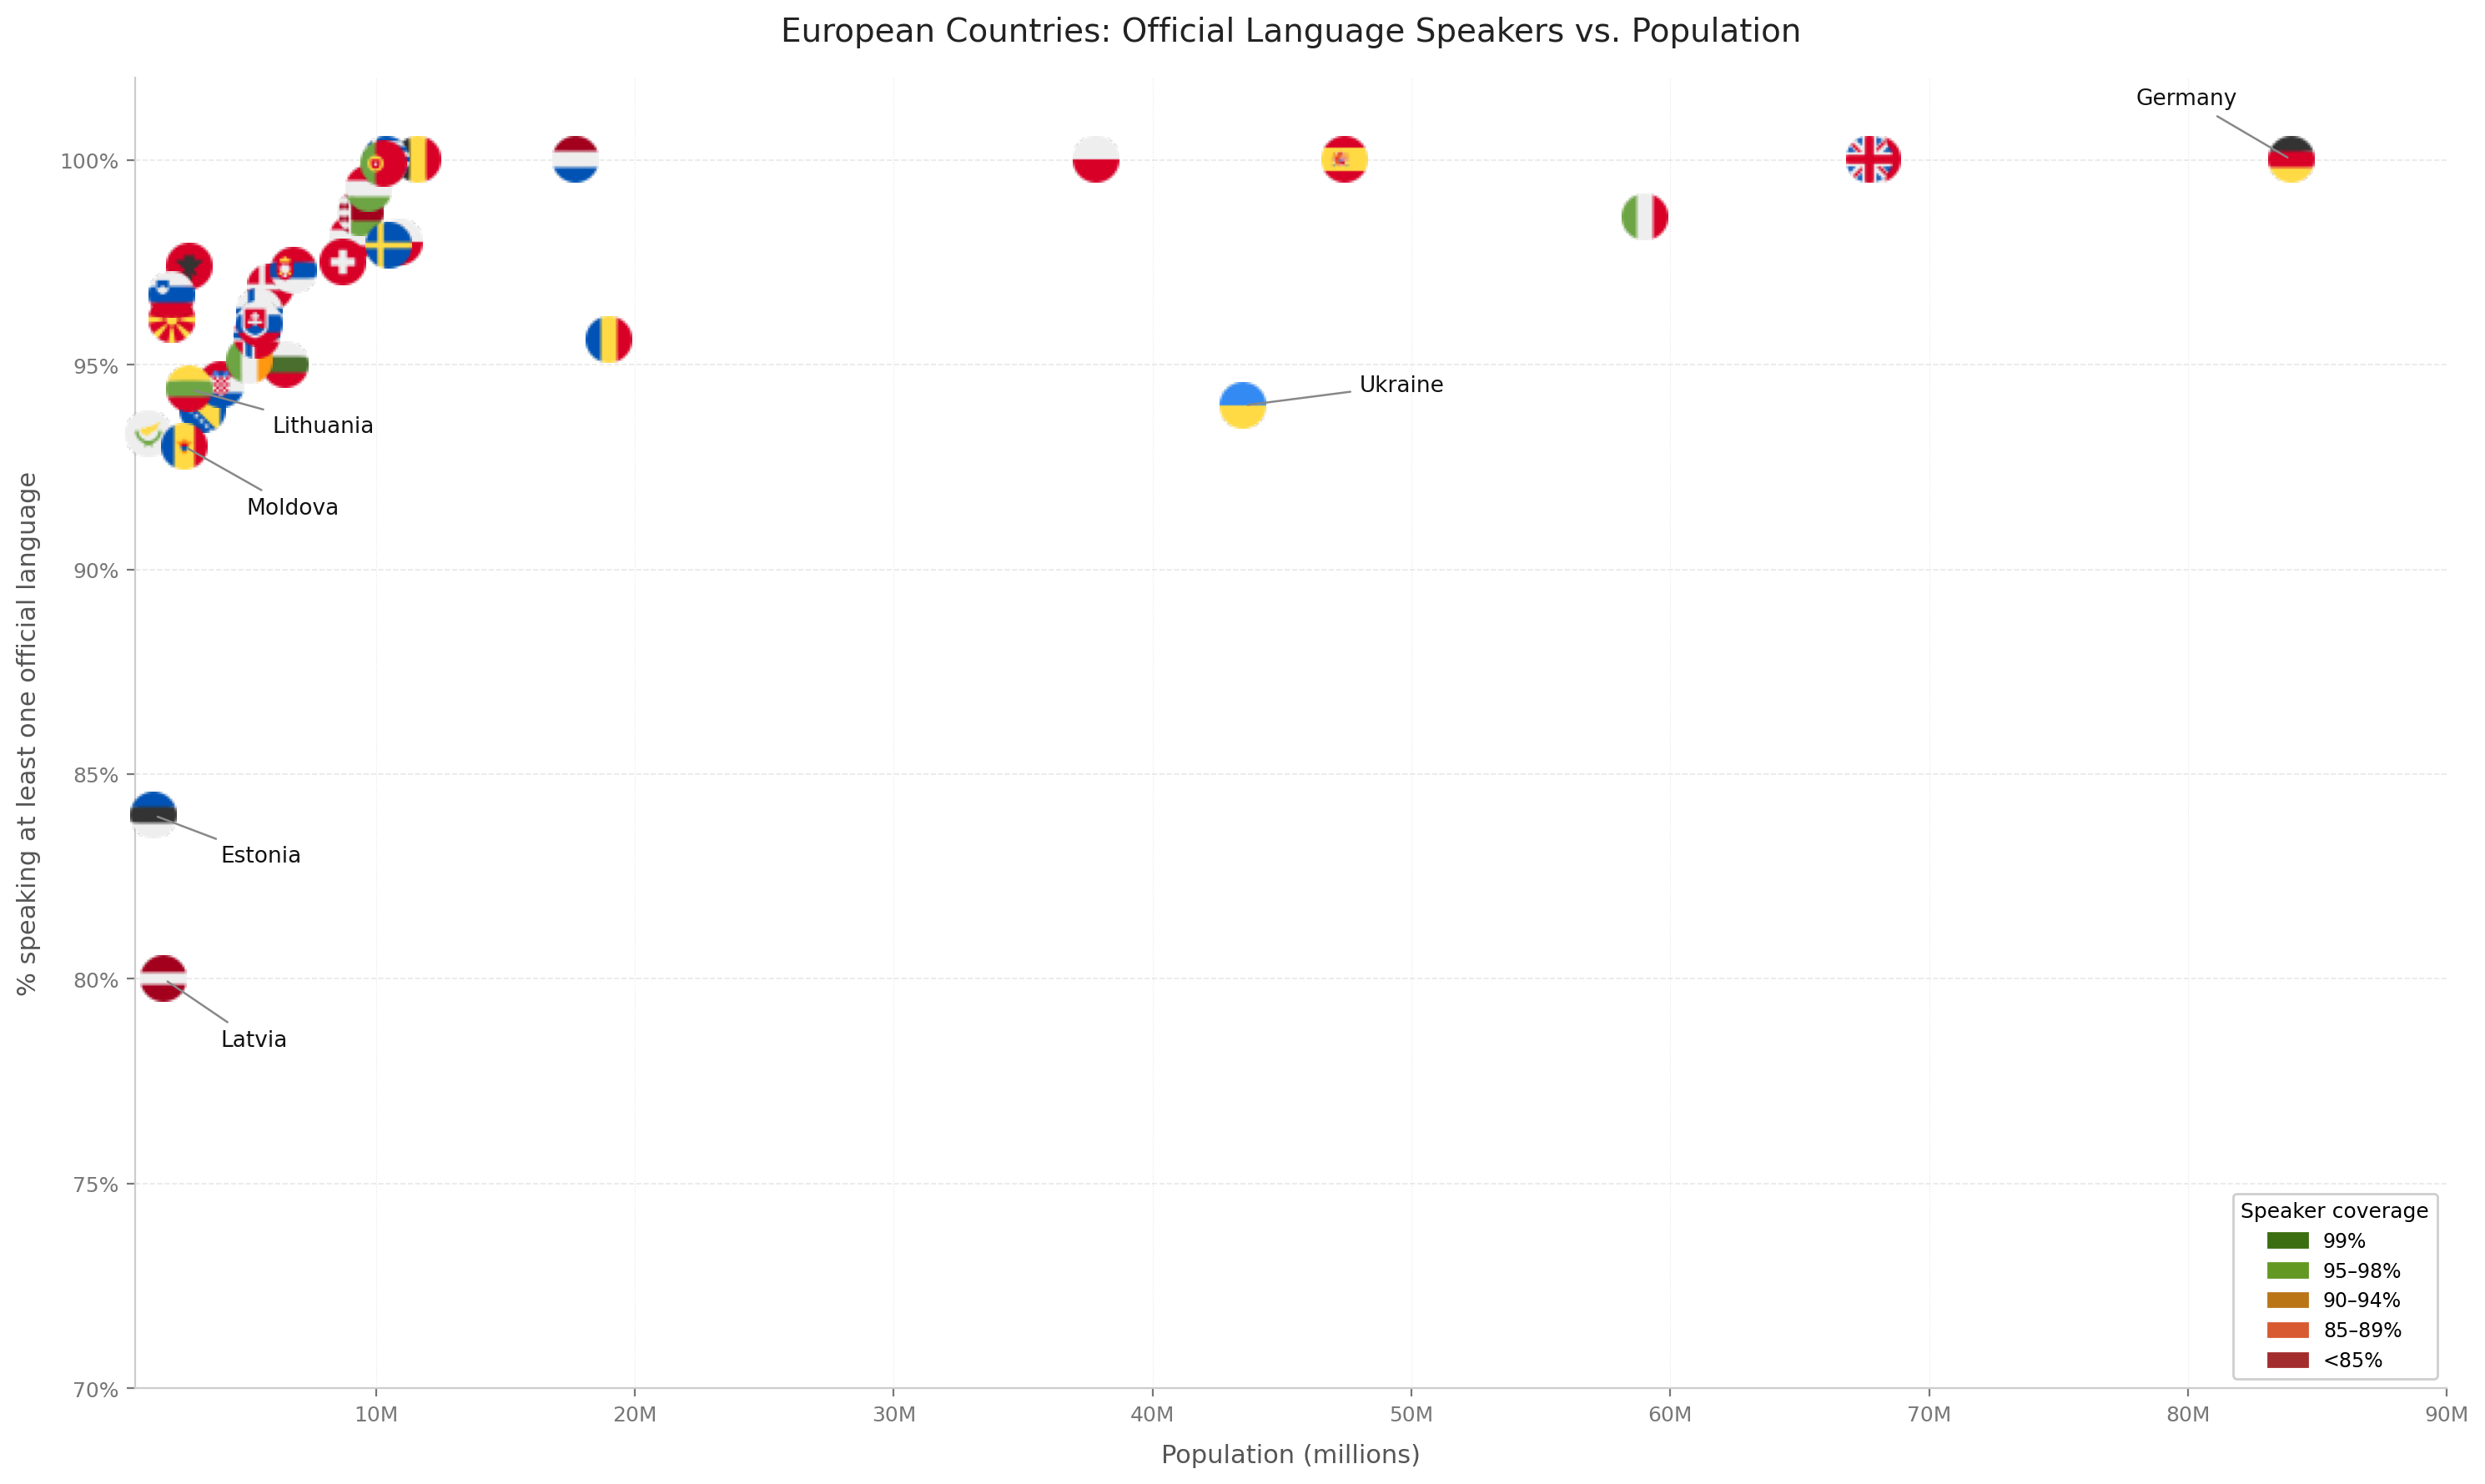

In [38]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import subprocess, io

FLAG_DIR = "tmp/circle-flags/flags/node_modules/circle-flags/flags"

countries = [
    ("Albania","al",2.8,98), ("Austria","at",9.1,99),
    ("Belarus","by",9.4,99), ("Belgium","be",11.6,99), ("Bosnia & Herz.","ba",3.3,99),
    ("Bulgaria","bg",6.5,95), ("Croatia","hr",4.0,99), ("Cyprus","cy",1.2,99),
    ("Czech Republic","cz",10.9,98), ("Denmark","dk",5.9,99), ("Estonia","ee",1.4,84),
    ("Finland","fi",5.5,99), ("France","fr",68.0,99), ("Germany","de",84.0,99),
    ("Greece","gr",10.4,99), ("Hungary","hu",9.7,99),
    ("Ireland","ie",5.1,99), ("Italy","it",59.0,98), ("Latvia","lv",1.8,80),
    ("Lithuania","lt",2.8,95), ("Moldova","md",2.6,93),
    ("Netherlands","nl",17.7,99), ("North Macedonia","mk",2.1,97), ("Norway","no",5.4,99),
    ("Poland","pl",37.8,99), ("Portugal","pt",10.3,99), ("Romania","ro",19.0,95),
    ("Serbia","rs",6.8,97), ("Slovakia","sk",5.5,96), ("Slovenia","si",2.1,97),
    ("Spain","es",47.4,99), ("Sweden","se",10.5,97), ("Switzerland","ch",8.7,99),
    ("Ukraine","ua",43.5,94), ("United Kingdom","gb",67.7,99),
]

names = [c[0] for c in countries]
isos  = [c[1] for c in countries]
pops  = np.array([c[2] for c in countries])
pcts  = np.array([c[3] for c in countries], dtype=float)

jittered_pcts = pcts.copy()
for val in np.unique(pcts):
    idx = np.where(pcts == val)[0]
    if len(idx) > 1:
        sorted_idx = idx[np.argsort(pops[idx])]
        n = len(sorted_idx)
        offsets = np.linspace(-(n-1)/2 * 0.6, (n-1)/2 * 0.6, n)
        for i, si in enumerate(sorted_idx):
            jittered_pcts[si] = val + offsets[i]

jittered_pcts = np.clip(jittered_pcts, None, 100)

def tier_color(p):
    if p >= 99: return "#3B6D11"
    if p >= 95: return "#639922"
    if p >= 90: return "#BA7517"
    if p >= 85: return "#D85A30"
    return "#A32D2D"

def load_circle_flag(iso, size=20):
    svg_path = f"{FLAG_DIR}/{iso}.svg"
    result = subprocess.run(
        ['rsvg-convert', '-w', str(size), '-h', str(size), '-f', 'png', svg_path],
        capture_output=True
    )
    img = Image.open(io.BytesIO(result.stdout)).convert('RGBA')
    return np.array(img)

flag_cache = {iso: load_circle_flag(iso, size=20) for iso in isos}

fig, ax = plt.subplots(figsize=(15, 9), dpi=200)
# fig.patch.set_facecolor("#FAFAF8")
# ax.set_facecolor("#F4F3EE")
ax.set_xlim(0.7, 90)
ax.set_ylim(75, 102)

ax.set_xlabel("Population (millions)", fontsize=11, color="#555", labelpad=8)
ax.set_ylabel("% speaking at least one official language", fontsize=11, color="#555", labelpad=8)
ax.set_title("European Countries: Official Language Speakers vs. Population",
             fontsize=14, fontweight="normal", color="#222", pad=16)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}M"))
ax.set_yticks([70,75,80,85,90,95,100])
ax.set_yticklabels(["70%","75%","80%","85%","90%","95%","100%"], fontsize=8)
ax.tick_params(colors="#777", labelsize=9)
ax.spines[["top","right"]].set_visible(False)
ax.spines[["left","bottom"]].set_color("#ccc")
ax.grid(axis="y", color="#ddd", linewidth=0.6, linestyle="--", zorder=0, alpha=0.7)
ax.grid(axis="x", color="#ddd", linewidth=0.4, linestyle=":", zorder=0, alpha=0.7)

for name, iso, pop, pct, jpct in zip(names, isos, pops, pcts, jittered_pcts):
    arr = flag_cache[iso]
    im = OffsetImage(arr, zoom=1.0)
    ab = AnnotationBbox(im, (pop, jpct), frameon=False, zorder=5, pad=0.0)
    ax.add_artist(ab)

label_cfg = {
    "Estonia":   {"xytext": (4,   83.0), "ha": "left"},
    "Latvia":    {"xytext": (4,   78.5), "ha": "left"},
    "Lithuania": {"xytext": (6,   93.5), "ha": "left"},
    "Ukraine":   {"xytext": (48,  94.5), "ha": "left"},
    "Moldova":   {"xytext": (5,  91.5), "ha": "left"},
    "Germany":   {"xytext": (78, 101.5), "ha": "left"},
}
for name, iso, pop, pct, jpct in zip(names, isos, pops, pcts, jittered_pcts):
    if name in label_cfg:
        cfg = label_cfg[name]
        ax.annotate(name, xy=(pop, jpct), xytext=cfg["xytext"],
            fontsize=9.5, color="#111",
            ha=cfg["ha"], va="center", zorder=10,
            arrowprops=dict(arrowstyle="-", color="#888", lw=0.9))

legend_items = [
    mpatches.Patch(color="#3B6D11", label="99%"),
    mpatches.Patch(color="#639922", label="95–98%"),
    mpatches.Patch(color="#BA7517", label="90–94%"),
    mpatches.Patch(color="#D85A30", label="85–89%"),
    mpatches.Patch(color="#A32D2D", label="<85%"),
]
ax.legend(handles=legend_items, title="Speaker coverage", title_fontsize=9,
          fontsize=8.5, loc="lower right", framealpha=0.95,
          edgecolor="#ccc", facecolor="white")

plt.tight_layout()
out = "european_language_chart.png"
plt.savefig(out, dpi=250, bbox_inches="tight", facecolor=fig.get_facecolor())
# print("Saved:", out)